# Objetivo do trabalho
Uso do resNet18 para detecção de cancer de intestino
- Dateset: LC25000
- 5000 imagens de não cancer
- 5000 imagens de cancer
- resolução transformadas: 256 x 256 pixeis

In [1]:
import tqdm
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import kagglehub
import shutil
from typing import Tuple
from PIL import Image
from imblearn.combine import SMOTETomek
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2
import os
import datetime
import torchvision
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tabulate import tabulate
import seaborn as sns
import copy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"Using: {torch.cuda.get_device_name(0)}")
    print(f"CUDA: {torch.version.cuda}")
else:
    print("CUDA is not available. Using CPU.")

Using: NVIDIA L4
CUDA: 12.6


In [3]:
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
shutil.copytree(path, "/content/", dirs_exist_ok=True)
!ls lung_colon_image_set

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
colon_image_sets  lung_image_sets


In [4]:
def generate_csv(path):
    path_to_dataset = pathlib.Path(path)
    LC25000Formatter(input_path = path_to_dataset, output_csv = "nb_lc25000.csv").run()


def get_formatted_datasets(path="/content/lung_colon_image_set/colon_image_sets", csv_path="/content/nb_lc25000.csv"):
    generate_csv(path)

    dataframe = pd.read_csv(csv_path)
    x_train, x_test, y_train, y_test = train_test_split(
        dataframe["path"],
        dataframe["label"],
        test_size=0.2,
        random_state=42,
        stratify=dataframe["label"]
    )

    df_train = pd.DataFrame({"path": x_train, "label": y_train})
    df_test = pd.DataFrame({"path": x_test, "label": y_test})  

    X_train, X_validation, y_train, y_validation = train_test_split(
    df_train["path"],
    df_train["label"],
    test_size=0.1,
    random_state=42,
    stratify=df_train["label"]
    )

    df_train = pd.DataFrame({"path": X_train, "label": y_train})
    df_validation = pd.DataFrame({"path": X_validation, "label": y_validation})


    return df_train, df_validation, df_test

class LC25000Formatter:
    def __init__(self, input_path, output_csv):
        self.input_path = input_path
        self.output_csv_path = output_csv

    def run(self):
        df = self.process_directory(self.input_path)
        df.to_csv(self.output_csv_path, index=False)
        print(f"CSV salvo com sucesso em: {self.output_csv_path}")

    def process_directory(self, input_path: str):
        label_map = {
            "colon_n": int(0),
            "colon_aca": int(1)
        }
        image_extensions = ['.jpg', '.jpeg', '.png']
        image_paths = list(self.input_path.glob('**/*'))

        data = []
        for path in tqdm.tqdm(image_paths):
            if path.suffix.lower() in image_extensions and path.is_file():
                label = path.parent.name
                segmentation = path.parent.name
                data.append({
                    "path": str(path.resolve()),
                    "label": label_map[label],
                    "segmentation": segmentation
                })

        df = pd.DataFrame(data)
        return df

In [5]:
class LC25000Dataset(Dataset):
    def __init__(self, df, target_column, transforms=None):
        self._df = df.reset_index(drop=True)
        self._target_column = target_column
        self._transforms = transforms

    def __len__(self):
        return len(self._df)

    def __getitem__(self, idx):
        row = self._df.iloc[idx]
        image_file_path = row["path"]


        if not os.path.exists(image_file_path):
            raise FileNotFoundError(f"Imagem não encontrada: {image_file_path}")

        image = Image.open(image_file_path).convert("RGB")
        image = np.array(image)
        if self._transforms is not None:
            image = self._transforms(image=image)["image"]
        label = row[self._target_column]
        return image, label

    def show_img(self, idx):
        '''Plot image'''
        img, label = self.__getitem__(idx)
        if isinstance(img, torch.Tensor):
            img = img.numpy().transpose(1, 2, 0)
        plt.figure(figsize=(16, 8))
        plt.axis('off')
        plt.imshow(img)
        plt.title(label)
        plt.pause(0.001)

class LC25000DatasetMemory(Dataset):
    def __init__(self, dataframe, transforms=None, target_column="label"):
        self.dataframe = dataframe
        self.transforms = transforms
        self.target_column = target_column

        self.images = []
        self.labels = []

        for idx, row in dataframe.iterrows():
            image_path = row["path"]
            image = Image.open(image_path).convert("RGB")
            image_np = np.array(image)

            if self.transforms:
                transformed = self.transforms(image=image_np)
                image_tensor = transformed["image"]
            else:
                image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)  # fallback

            self.images.append(image_tensor)
            self.labels.append(row[target_column])

        self.images = torch.stack(self.images)
        self.labels = torch.tensor(self.labels)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


class LC25000DatasetConfig:
    VAL_SIZE = 0.2
    SEED = 0x40

    TEST_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    TRAIN_TRANSFORMS = A.Compose([
        A.Resize(224, 224),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

def get_dataloaders(df_train, df_validation, df_test, batch_size = 1, num_workers = 0, memory_mode = False):
    if not memory_mode:
        dataset_train = LC25000Dataset(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000Dataset(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000Dataset(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

    else:
        dataset_train = LC25000DatasetMemory(
            df_train,
            transforms=LC25000DatasetConfig.TRAIN_TRANSFORMS,
            target_column="label",
        )

        dataset_validation = LC25000DatasetMemory(
            df_validation,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataset_test = LC25000DatasetMemory(
            df_test,
            transforms=LC25000DatasetConfig.TEST_TRANSFORMS,
            target_column="label",
        )

        dataloader_train = DataLoader(dataset_train, batch_size= batch_size,pin_memory = True, shuffle= True, num_workers = num_workers)
        dataloader_validation = DataLoader(dataset_validation, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)
        dataloader_test = DataLoader(dataset_test, batch_size= batch_size, pin_memory = True,shuffle= False, num_workers = num_workers)

        return dataloader_train, dataloader_validation, dataloader_test

In [6]:
df_train, df_validation, df_test = get_formatted_datasets()
print(f"\nNumber of images in training dataset: {len(df_train)}")
print(f"Number of images in test dataset: {len(df_validation)}")
print(f"Number of images in validation dataset: {len(df_test)}")

100%|██████████| 10002/10002 [00:00<00:00, 25597.50it/s]


CSV salvo com sucesso em: nb_lc25000.csv

Number of images in training dataset: 7200
Number of images in test dataset: 800
Number of images in validation dataset: 2000


In [7]:
batch_size = 64
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test, batch_size, 2, memory_mode = True)

### hiperparametros
- numero de canais de entrada: 3
- numero de classes de saída: 2
- taxa de aprendizado: 0.002
- Otimizador: Adamax
- β1 = 0.9, β2 = 0.999
- Weight Decay: 1e-4
- número de épocas: 50

In [8]:
in_channels = 3
output_features = 2
learning_rate = 1e-2
weight_decay = 1e-4
b1 = 0.9
b2 = 0.999
eps= 1e-08

In [9]:
model = torchvision.models.resnet18(num_classes=output_features)
optimizer = torch.optim.Adamax(model.parameters(), lr=learning_rate, betas=(b1, b2), eps=eps, weight_decay=weight_decay)

### Treinamento

In [10]:
criterion = torch.nn.CrossEntropyLoss()

def train_model(model, dataloader_train, dataloader_validation, optimizer, epochs = 10, patience = 0):
    model = model.to("cuda")
    device = "cuda"
    train_losses = []
    val_losses = []
    best_loss = float("inf")
    best_model = None
    epochs_no_improve = 0
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        total_loss_validation = 0

        for images, labels in dataloader_train:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size()[0]

        with torch.no_grad():
            model.eval() 

            for images, labels in dataloader_validation:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss_validation += loss.item() * images.size()[0]
            

        avg_train_loss = total_loss / len(dataloader_train.dataset)
        avg_val_loss = total_loss_validation / len(dataloader_validation.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model = copy.deepcopy(model)
            torch.save(model.state_dict(), f"{model.__class__.__name__}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        if patience > 0 and epochs_no_improve >= patience:
            print(f"\nEarly stopping ativado! Melhor Val Loss: {best_loss:.4f}")
            break

    return train_losses, val_losses, best_model



def test_model(model, device, dataloader_test):
    model = model.to(device)
    model.eval()  # Modo de avaliação
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader_test:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Cálculo das métricas
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print("Matriz de Confusão:")
    print(cm)

    return acc, precision, recall, f1, cm


In [11]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer, 50)

Epoch 1/50 | Train Loss: 0.2512 | Val Loss: 0.1307
Epoch 2/50 | Train Loss: 0.0863 | Val Loss: 0.2230
Epoch 3/50 | Train Loss: 0.0465 | Val Loss: 1.1276
Epoch 4/50 | Train Loss: 0.0365 | Val Loss: 0.8861
Epoch 5/50 | Train Loss: 0.0223 | Val Loss: 0.0287
Epoch 6/50 | Train Loss: 0.0384 | Val Loss: 0.0843
Epoch 7/50 | Train Loss: 0.0249 | Val Loss: 0.6620
Epoch 8/50 | Train Loss: 0.0246 | Val Loss: 0.5368
Epoch 9/50 | Train Loss: 0.0142 | Val Loss: 1.3790
Epoch 10/50 | Train Loss: 0.0181 | Val Loss: 0.1269
Epoch 11/50 | Train Loss: 0.0141 | Val Loss: 0.0963
Epoch 12/50 | Train Loss: 0.0210 | Val Loss: 0.3711
Epoch 13/50 | Train Loss: 0.0150 | Val Loss: 2.6857
Epoch 14/50 | Train Loss: 0.0191 | Val Loss: 0.1176
Epoch 15/50 | Train Loss: 0.0192 | Val Loss: 0.1579
Epoch 16/50 | Train Loss: 0.0203 | Val Loss: 2.1032
Epoch 17/50 | Train Loss: 0.0176 | Val Loss: 0.1453
Epoch 18/50 | Train Loss: 0.0061 | Val Loss: 0.0053
Epoch 19/50 | Train Loss: 0.0074 | Val Loss: 0.4888
Epoch 20/50 | Train L

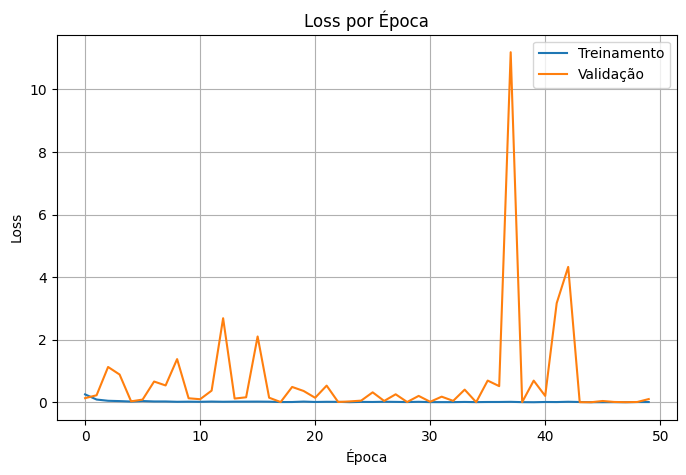

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9650
Precisão (weighted): 0.9673
Recall (weighted): 0.9650
F1-score (weighted): 0.9650
Matriz de Confusão:
[[1000    0]
 [  70  930]]


In [14]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.965  │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9673 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.965  │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.965  │
╘═════════════════════╧═════════╛


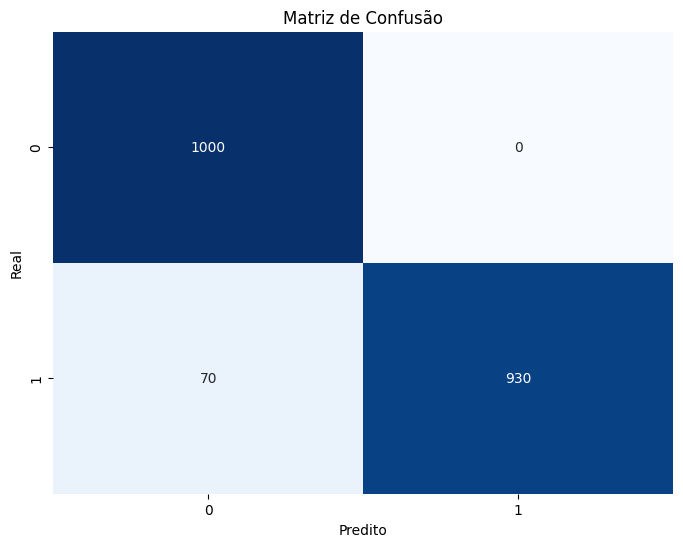

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()